<a href="https://colab.research.google.com/github/sYanXO/Volatility-Regime-Analysis/blob/main/Volatility_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [3]:
data = yf.download("INFY.NS",period="10y")
data.dropna()

/tmp/ipykernel_655/2902858957.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("INFY.NS",period="10y")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,INFY.NS,INFY.NS,INFY.NS,INFY.NS,INFY.NS
Date,,,,,
2016-03-16,439.851044,440.824311,431.874260,435.824495,5588850
2016-03-17,443.400696,446.454025,440.461885,441.549624,6474622
2016-03-18,455.480316,457.617637,443.495992,443.801343,8477422
2016-03-21,456.052917,457.617739,450.385184,453.419412,5138392
2016-03-22,454.163483,455.709249,447.312596,454.659667,7097950
...,...,...,...,...,...
2026-03-10,1295.599976,1321.000000,1284.099976,1320.000000,9600171
2026-03-11,1276.300049,1299.500000,1271.300049,1288.000000,7868891


In [4]:
data["returns"] = data["Close"].pct_change()
data.dropna()

Price,Close,High,Low,Open,Volume,returns
Ticker,INFY.NS,INFY.NS,INFY.NS,INFY.NS,INFY.NS,
Date,,,,,,
2016-03-17,443.400696,446.454025,440.461885,441.549624,6474622,0.008070
2016-03-18,455.480316,457.617637,443.495992,443.801343,8477422,0.027243
2016-03-21,456.052917,457.617739,450.385184,453.419412,5138392,0.001257
2016-03-22,454.163483,455.709249,447.312596,454.659667,7097950,-0.004143
2016-03-23,460.976318,462.083113,451.167472,454.182643,6333176,0.015001
...,...,...,...,...,...,...
2026-03-10,1295.599976,1321.000000,1284.099976,1320.000000,9600171,-0.014753
2026-03-11,1276.300049,1299.500000,1271.300049,1288.000000,7868891,-0.014897


Text(0.5, 1.0, 'INFY daily returns')

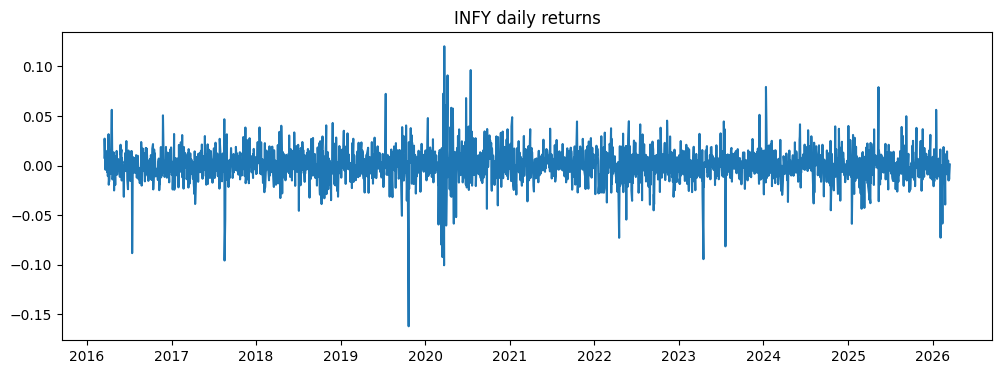

In [9]:
plt.figure(figsize=(12,4))
plt.plot(data["returns"])
plt.title("INFY daily returns")

In [ ]:
!pip install arch

In [15]:
from arch import arch_model
returns = (data["returns"]*100).dropna() # garch models work better with scaled % data, and NaNs removed

model = arch_model(returns,vol="GARCH",p=1,q=1)
result = model.fit(disp="off")

print(result.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -4639.43
Distribution:                  Normal   AIC:                           9286.86
Method:            Maximum Likelihood   BIC:                           9310.11
                                        No. Observations:                 2469
Date:                Mon, Mar 16 2026   Df Residuals:                     2468
Time:                        15:47:20   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0892  3.035e-02      2.940  3.287e-03 [2.973e-0

**We can see that alphaa + beta < 1 hence our garch modelling holds. Means volatility will revert back to normal.**

alpha tells us 8% of today's shock is carried into tomorrow
beta tells us 80% of yesterday's volatility persists into today
omega is baseline variance...even when nothing happens...there is some background noise

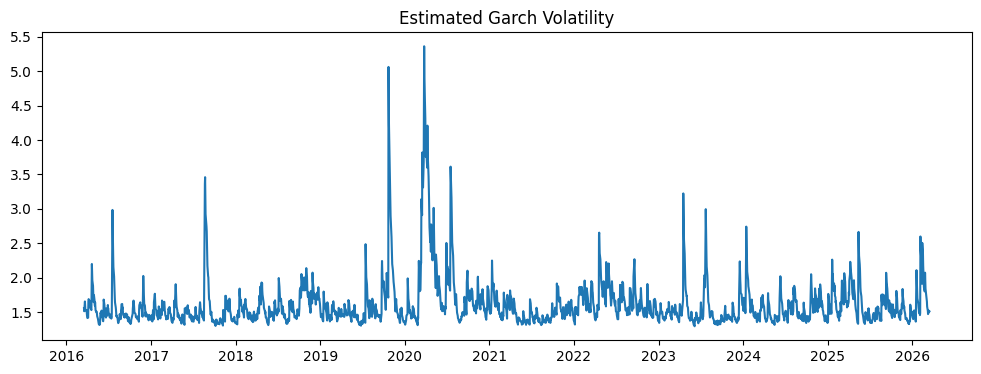

In [16]:
data["garch_vol"] = result.conditional_volatility
plt.figure(figsize=(12,4))
plt.plot(data["garch_vol"])
plt.title("Estimated Garch Volatility")
plt.show()

In [17]:
data["next_abs_return"] = data["returns"].shift(-1).abs()

high_vol = data[data["garch_vol"] > data["garch_vol"].quantile(0.8)]
low_vol = data[data["garch_vol"] < data["garch_vol"].quantile(0.2)]

print("Avg next move when volatility HIGH:", high_vol["next_abs_return"].mean())
print("Avg next move when volatility LOW:", low_vol["next_abs_return"].mean())

Avg next move when volatility HIGH: 0.014599944948486676
Avg next move when volatility LOW: 0.010954188153094619


**Observation:


Using a GARCH(1,1) model on INFY returns, periods with higher predicted volatility were followed by larger average next-day price movements ~1.46% compared to periods with low predicted volatility ~1.10%.This suggests the model captures volatility clustering and can provide a useful signal about the expected magnitude of future market movements, though not their direction.**

In [18]:
forecast = result.forecast(horizon=1)
forecast.variance.tail()

,h.1
Date,
2026-03-16,2.132368


In [19]:
predicted_volatility = np.sqrt(forecast.variance.iloc[-1,0])
print("Predicted Volatility tomorrow is = ", predicted_volatility)

Predicted Volatility tomorrow is =  1.4602630595054127


In [ ]:
################################################################################################

In [20]:
data["predicted volatility"] = result.conditional_volatility.shift(1)



data["abs_return"] = data["returns"].abs()

data[["predicted volatility","abs_return"]].corr()

,Price,predicted volatility,abs_return
,Ticker,,
Price,Ticker,,
predicted volatility,,1.000000,0.188292
abs_return,,0.188292,1.000000


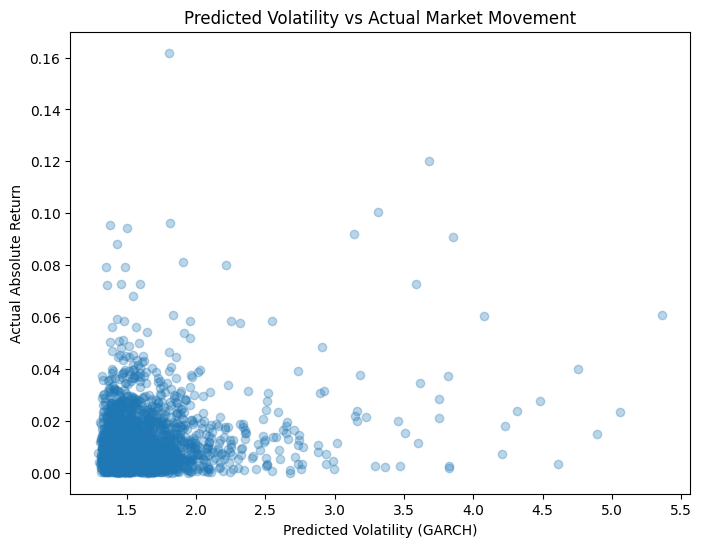

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(data["predicted volatility"], data["abs_return"], alpha=0.3)

plt.xlabel("Predicted Volatility (GARCH)")
plt.ylabel("Actual Absolute Return")
plt.title("Predicted Volatility vs Actual Market Movement")

plt.show()

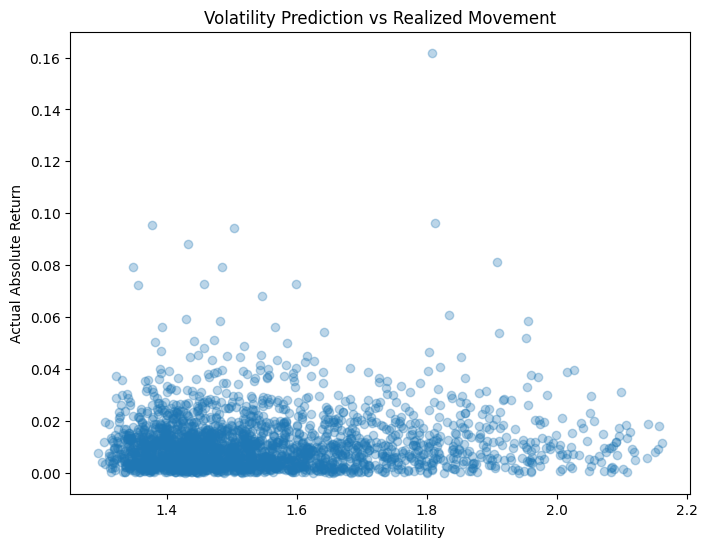

In [24]:
filtered = data[data["predicted volatility"] < data["predicted volatility"].quantile(0.95)]

plt.figure(figsize=(8,6))
plt.scatter(filtered["predicted volatility"], filtered["abs_return"], alpha=0.3)

plt.xlabel("Predicted Volatility")
plt.ylabel("Actual Absolute Return")
plt.title("Volatility Prediction vs Realized Movement")

plt.show()